# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

import plotly.express as px

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [ ]:
# seu código aqui

In [3]:
#Observar df
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65,1,1,0,0,0,0
9996,50,1,160,93,2,1,0,0,1,1
9997,40,1,158,66,2,2,0,0,1,0
9998,50,1,168,70,3,1,0,0,1,1


In [4]:
# verificar tipos de dados e prepresença de nulos
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [5]:
#Verificar dados incorretos na coluna Weight
base['weight'].unique()[:200]

array(['62', '85', '64', '82', '56', '67', '93', '95', '71', '68', '80',
       '60', '78', '112', '75', '52', '83', '69', '90', '45', '65', '59',
       '66', '74', '105', '73', '55', '70', '72', '63', '50', '107', '84',
       '77', '79', '76', '58', '115', '97', '53', '57', '49', '110', '94',
       '92', '87', '103', '88', '99', '100', '61', '48', '54', '51', '47',
       '91', '104', '81', '98', '108', '89', '101', '86', '65,5', '142',
       '96', '44', '41', '169', '116', '200', '64,8', '120', '117', '125',
       '106', '114', '113', '129', '124', '42', '123', '111', '102',
       '109', '46', '139', '150', '138', '131', '43', '83,6', '134',
       '106,5', '121', '40', '141', '119', '126', '177', '165', '122',
       '62,3', '118', '89,5', '132', '155', '130', '159', '84,6', '140',
       '82,3', '30', '67,9', '127', '67,5', '74,3', '149', '180', '128',
       '60,2', '64,5', '58,7', '90,5', '37', '80,8', '166', '161', '92,2',
       '75,6', '136', '82,9', '154', '68,9', '170'

In [6]:
base['weight'] = base['weight'].str.replace(',', '.', regex=False)

In [7]:
#Verificar dados incorretos na coluna Weight
base['weight'].unique()[:200]

array(['62', '85', '64', '82', '56', '67', '93', '95', '71', '68', '80',
       '60', '78', '112', '75', '52', '83', '69', '90', '45', '65', '59',
       '66', '74', '105', '73', '55', '70', '72', '63', '50', '107', '84',
       '77', '79', '76', '58', '115', '97', '53', '57', '49', '110', '94',
       '92', '87', '103', '88', '99', '100', '61', '48', '54', '51', '47',
       '91', '104', '81', '98', '108', '89', '101', '86', '65.5', '142',
       '96', '44', '41', '169', '116', '200', '64.8', '120', '117', '125',
       '106', '114', '113', '129', '124', '42', '123', '111', '102',
       '109', '46', '139', '150', '138', '131', '43', '83.6', '134',
       '106.5', '121', '40', '141', '119', '126', '177', '165', '122',
       '62.3', '118', '89.5', '132', '155', '130', '159', '84.6', '140',
       '82.3', '30', '67.9', '127', '67.5', '74.3', '149', '180', '128',
       '60.2', '64.5', '58.7', '90.5', '37', '80.8', '166', '161', '92.2',
       '75.6', '136', '82.9', '154', '68.9', '170'

In [9]:
#Corrigir Coluna Weight de object para int
base['weight'] = pd.to_numeric(base['weight'], errors='coerce')

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [12]:
#Verificar Outliers
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


Altura max de 250cm é um valor incompativel, portando será filtrado e retirado qualquer valor acima de 220cm.
Altura de 70cm pode ser um Outlier, como mesmo em pessoas com nanismo a altura dende a ser superior a 120cm, será removido valores aboixo desse valor, com o objetico de manter o modelo mais geral, sem casos raros de alturar muito baixas, quem podem ser erros.

In [13]:
base[base['height'] > 220]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
6486,58,1,250,86.0,3,1,0,0,1,1


In [15]:
base= base[base['height'] <= 220]

In [16]:
base[base['height'] < 120]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
224,60,2,76,55.0,1,1,0,0,1,0
3420,40,1,100,70.0,1,1,0,0,1,0
7116,56,2,117,78.0,1,1,1,0,1,1
7598,40,2,70,72.0,1,1,0,0,1,0
8171,48,2,97,170.0,1,1,1,0,1,1
8677,54,2,119,89.0,1,1,0,0,1,1


In [17]:
base= base[base['height'] >= 120]

In [18]:
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,53.290003,1.345142,164.340338,74.293716,1.365056,1.222356,0.088862,0.053738,0.797058,0.503052
std,6.795256,0.475438,7.952128,14.537342,0.677639,0.565728,0.284559,0.225510,0.402210,0.500016
min,30.000000,1.000000,120.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
base[base['weight'] < 40]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
3752,42,1,120,30.0,1,1,0,0,1,0
5794,48,1,151,37.0,1,1,0,0,1,0


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


In [ ]:
# seu código aqui

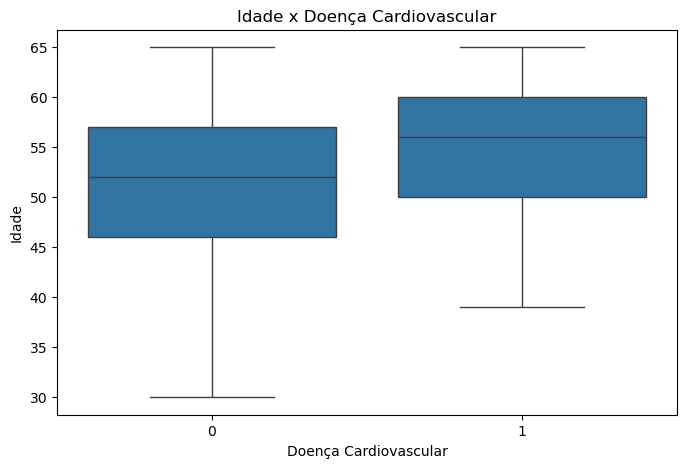

In [20]:
#Plot Idade x Doença Cardiovascular
plt.figure(figsize=(8,5))
sns.boxplot(x='cardio_disease', y='age', data=base)

plt.title('Idade x Doença Cardiovascular')
plt.xlabel('Doença Cardiovascular')
plt.ylabel('Idade')
plt.show()

Observamos que quanto maior a idade maior a probabilidade de Doença Cardiovascular.

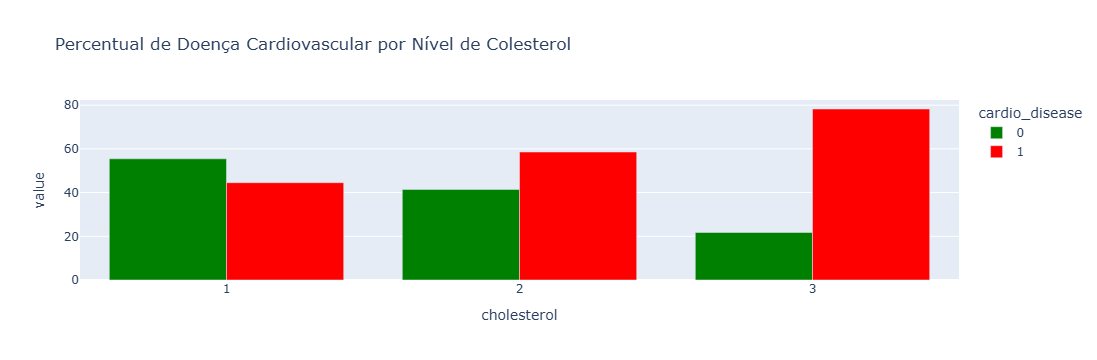

In [21]:
#Plot Colesterol X Doença Cardiovascular
colesterol_cardio = pd.crosstab(
    base['cholesterol'],
    base['cardio_disease'],
    normalize='index'
) * 100

fig = px.bar(
    colesterol_cardio,
    barmode='group',
    title='Percentual de Doença Cardiovascular por Nível de Colesterol',
    color_discrete_sequence=['Green', 'Red']
)

fig.show()

Observa-se que niveis médios e altos de colesterol aumentam a chance de Doenças Carviovasculares. Niveis baixos há mais pessoas sem doença, enquanto em nivel médio e alto há um aumento de doenças que ultrapassa o de pessoas saudáveis.

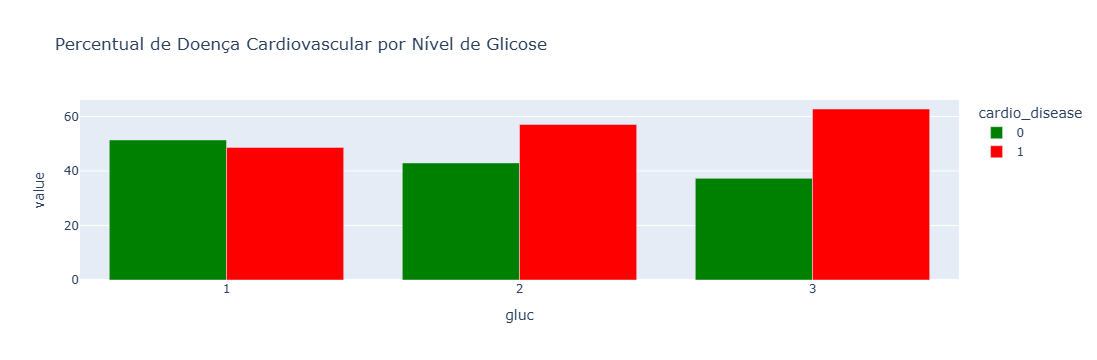

In [22]:
#Plot Glicose X Doença Cardiovascular
glucose_cardio = pd.crosstab(
    base['gluc'],
    base['cardio_disease'],
    normalize='index'
) * 100

fig = px.bar(
    glucose_cardio,
    barmode='group',
    title='Percentual de Doença Cardiovascular por Nível de Glicose',
    color_discrete_sequence=['Green', 'Red']
)

fig.show()

Observa-se que niveis médios e altos de glicose aumentam a chance de Doenças Carviovasculares. Niveis baixos há mais pessoas sem doença, enquanto em nivel médio e alto há um aumento de doenças que ultrapassa o de pessoas saudáveis.

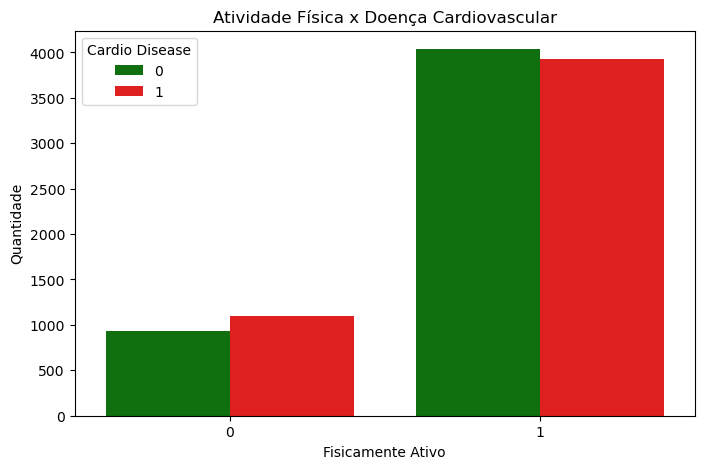

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='active',
              hue='cardio_disease',
              data=base,
              palette=['Green', 'Red'])

plt.title('Atividade Física x Doença Cardiovascular')
plt.xlabel('Fisicamente Ativo')
plt.ylabel('Quantidade')
plt.legend(title='Cardio Disease')
plt.show()

Observa-se indivíduos físicamene ativos possuem menos doenças cardiovasculares do que os individuos sedentários.

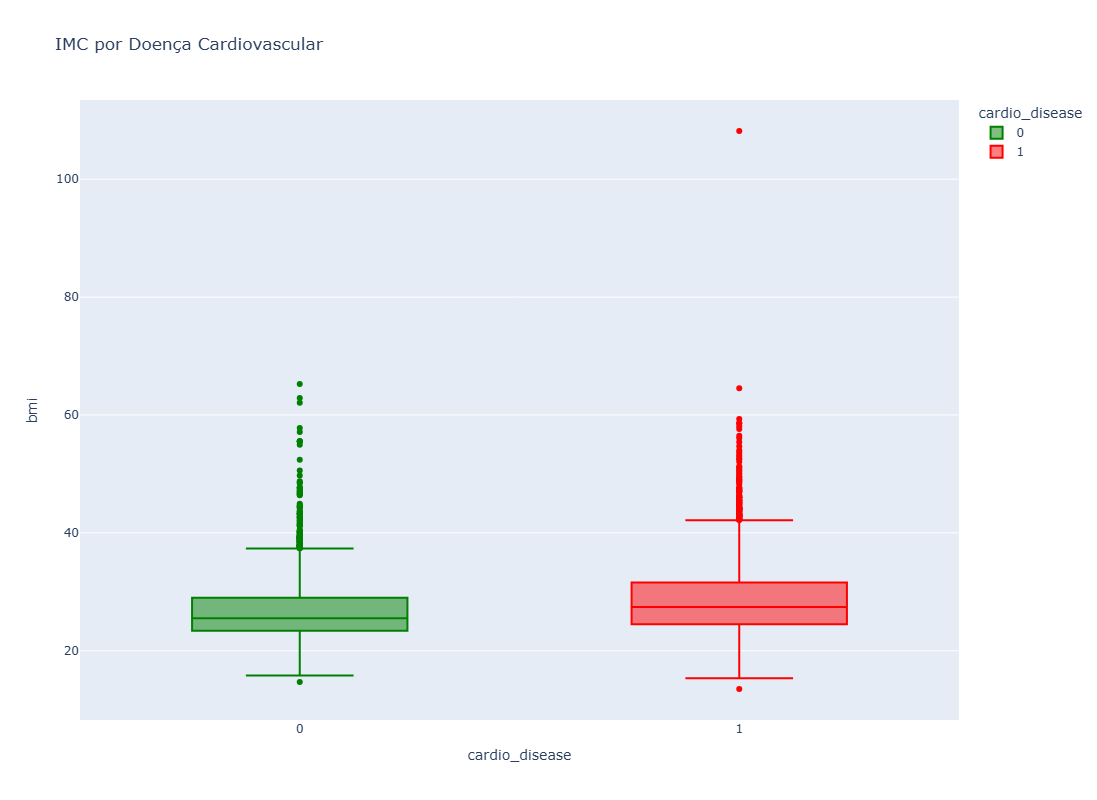

In [24]:
base['bmi'] = base['weight'] / ((base['height']/100)**2)

fig = px.box(
    base,
    x='cardio_disease',
    y='bmi',
    color='cardio_disease',
    title='IMC por Doença Cardiovascular',
    color_discrete_map={
        0: 'Green',
        1: 'Red'   
    },
    width=900,
    height=800
)
fig.show()

Observa-se que um maior IMC, resulta em um aumento nos individuos com doenças cardiovasculares

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



In [ ]:
# seu código aqui

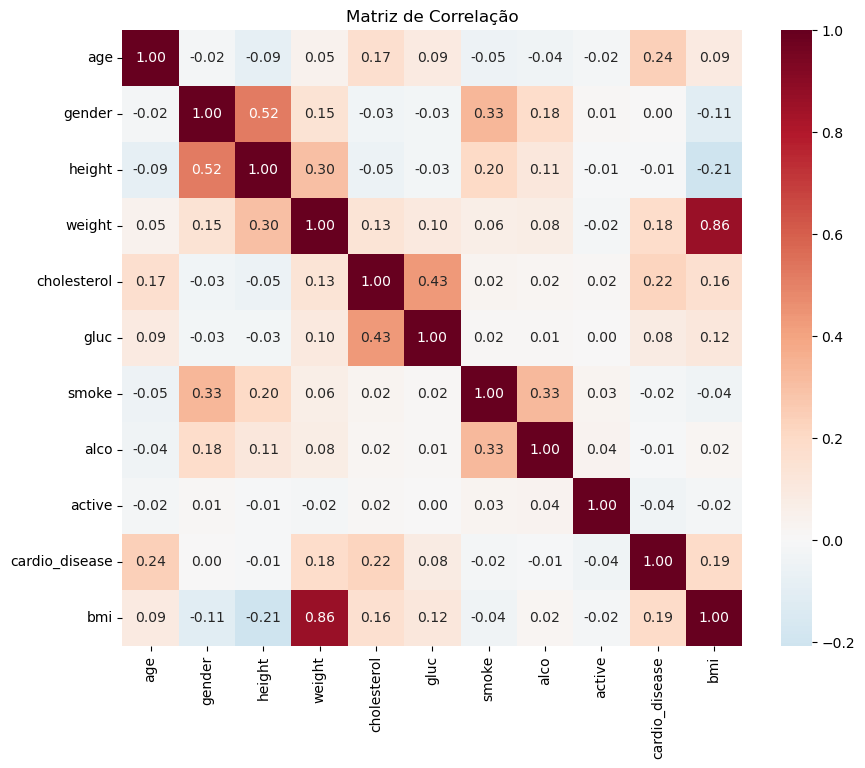

In [25]:
# Matriz de correlação
corr = base.corr(numeric_only=True)

# Visualização
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

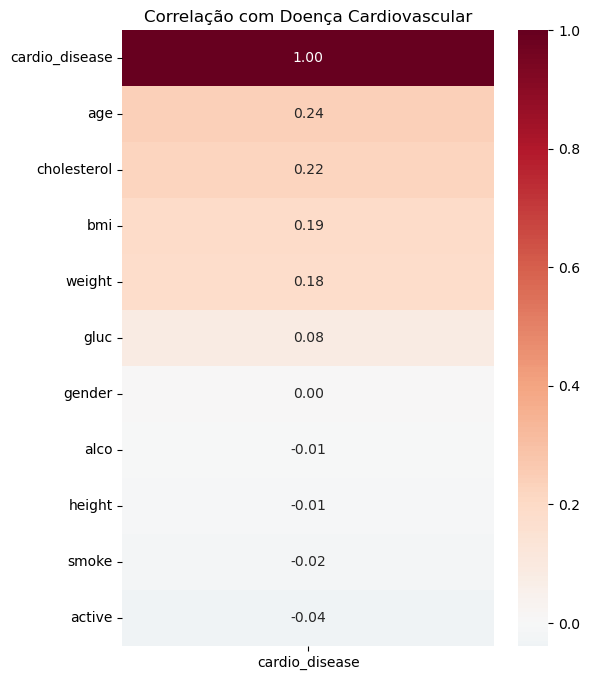

In [26]:
plt.figure(figsize=(6,8))

corr_cardio = corr[['cardio_disease']].sort_values(
    by='cardio_disease',
    ascending=False
)

sns.heatmap(
    corr_cardio,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title('Correlação com Doença Cardiovascular')
plt.show()

A análise de correlação mostrou que idade (0,24) e colesterol (0,22) são as variáveis mais relacionadas à ocorrência de doenças cardiovasculares, indicando que pacientes mais velhos e com níveis elevados de colesterol tendem a apresentar maior risco. O IMC (0,19) e o peso (0,18) também apresentaram associação positiva com a doença e, por carregarem informações semelhantes sobre a composição corporal, podem ser considerados redundantes em alguns modelos. A glicose (0,08) apresentou uma relação positiva, porém fraca, sugerindo que sua contribuição pode ser mais relevante quando combinada com outras variáveis. Já a atividade física (-0,04) mostrou uma correlação negativa, indicando um possível efeito protetor contra a doença cardiovascular. Por fim, tabagismo (-0,02) e consumo de álcool (-0,01) apresentaram correlações muito baixas.

In [27]:
base[base['bmi'].isna()]

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease,bmi


In [28]:
#Remoção de Height e Weight, pois são redundantes com a adição do BMI (IMC)
base.drop(['height', 'weight'], axis=1, inplace=True)

In [29]:
print(base.columns)

Index(['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
       'cardio_disease', 'bmi'],
      dtype='object')


# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [ ]:
# seu código aqui

In [30]:
# Variáveis explicativas
X = base.drop('cardio_disease', axis=1)

# Variável alvo
y = base['cardio_disease']

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Sim, é necessário padronizar, devido aos dados 'age' e BMI estarem em uma escala muito diferente das outras colunas.

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
#Verificar Balanceamento
print(y.value_counts())

print('\nPercentual:')
print(y.value_counts(normalize=True) * 100)

cardio_disease
1    5027
0    4966
Name: count, dtype: int64

Percentual:
cardio_disease
1    50.305214
0    49.694786
Name: proportion, dtype: float64


Não é necessário balancear pois a proporção está muito próxima de 50/50.

In [46]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (6995, 8)
X_test: (2998, 8)
y_train: (6995,)
y_test: (2998,)


In [47]:
print('Treino:')
print(y_train.value_counts(normalize=True) * 100)

print('\nTeste:')
print(y_test.value_counts(normalize=True) * 100)

Treino:
cardio_disease
1    50.307362
0    49.692638
Name: proportion, dtype: float64

Teste:
cardio_disease
1    50.3002
0    49.6998
Name: proportion, dtype: float64


In [ ]:
#smote = SMOTE(random_state=42)
#X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, y_train)

In [48]:
X_train

array([[ 0.69305676, -0.72913649,  2.40510466, ..., -0.24233364,
         0.51114517,  0.40894547],
       [ 1.57260658, -0.72913649, -0.5391913 , ..., -0.24233364,
         0.51114517,  1.11436662],
       [-0.18649306,  1.37148532, -0.5391913 , ...,  4.1265422 ,
         0.51114517, -0.20955815],
       ...,
       [ 0.10669021,  1.37148532,  0.93295668, ..., -0.24233364,
         0.51114517,  0.34199525],
       [-1.06604289, -0.72913649, -0.5391913 , ..., -0.24233364,
         0.51114517, -0.60246548],
       [ 0.39987349,  1.37148532, -0.5391913 , ...,  4.1265422 ,
         0.51114517, -0.32077893]], shape=(6995, 8))

In [49]:
X_test

array([[-0.47967634, -0.72913649,  0.93295668, ..., -0.24233364,
         0.51114517, -0.06171668],
       [-1.65240944, -0.72913649,  0.93295668, ..., -0.24233364,
         0.51114517, -0.02937888],
       [-0.18649306, -0.72913649,  2.40510466, ..., -0.24233364,
        -1.95639138, -0.78967091],
       ...,
       [-0.47967634, -0.72913649,  2.40510466, ..., -0.24233364,
         0.51114517,  1.43460265],
       [ 0.10669021, -0.72913649, -0.5391913 , ..., -0.24233364,
         0.51114517,  2.17280528],
       [-1.94559271, -0.72913649, -0.5391913 , ..., -0.24233364,
        -1.95639138, -0.94197714]], shape=(2998, 8))

In [50]:
y_train

2083    1
7466    1
6577    1
454     1
2775    0
       ..
7118    0
4322    1
7714    0
1541    0
4101    1
Name: cardio_disease, Length: 6995, dtype: int64

In [51]:
y_test

9610    1
6257    0
8445    1
8387    0
7433    1
       ..
6627    1
1866    1
6804    1
9127    1
5448    0
Name: cardio_disease, Length: 2998, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [ ]:
# seu código aqui

In [52]:
# Treinamento
modelo = LogisticRegression(random_state=0)

modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
print('Intercepto:')
print(modelo.intercept_)

Intercepto:
[0.03209001]


In [54]:
coeficientes = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

print(coeficientes)

      Variavel  Coeficiente
0          age     0.434114
2  cholesterol     0.432789
7          bmi     0.384861
1       gender     0.053581
5         alco    -0.005514
4        smoke    -0.034540
6       active    -0.078543
3         gluc    -0.081327


In [67]:
y_pred = modelo.predict(X_test)

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.65      0.63      1490
           1       0.64      0.60      0.62      1508

    accuracy                           0.63      2998
   macro avg       0.63      0.63      0.63      2998
weighted avg       0.63      0.63      0.63      2998



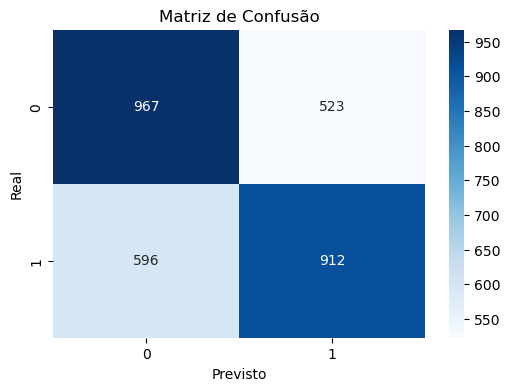

In [70]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

O modelo de Regressão Logística apresentou acurácia de 63%, com desempenho equilibrado entre as classes de pacientes com e sem doença cardiovascular. As métricas de precisão, recall e F1-score ficaram próximas de 0,63, indicando uma capacidade moderada de classificação. Apesar dos resultados serem superiores ao acaso, o recall de 60% para a classe de pacientes com doença cardiovascular mostra que uma parcela considerável dos casos positivos não é identificada pelo modelo.
O principal ponto de atenção é a quantidade de falsos negativos, indicando que aproximadamente 40% dos pacientes com doença não foram identificados pelo modelo. Apesar de apresentar um desempenho equilibrado entre as classes e uma acurácia geral de 63%, os resultados sugerem que a Regressão Logística possui capacidade preditiva moderada para este problema. Em aplicações médicas, onde a identificação correta dos pacientes doentes é fundamental, seria recomendável explorar técnicas adicionais de ajuste de limiar de decisão ou modelos mais robustos para aumentar a sensibilidade (recall) da classe positiva.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [ ]:
# seu código aqui

In [71]:
y_pred = modelo.predict(X_test)

print(y_pred)

[1 0 1 ... 1 1 0]


In [73]:
resultado = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': y_pred
})

print(resultado.head(10))

   Real  Previsto
0     1         1
1     0         0
2     1         1
3     0         0
4     1         0
5     1         1
6     1         0
7     1         0
8     0         1
9     1         0


In [78]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calcular a AUC
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.63


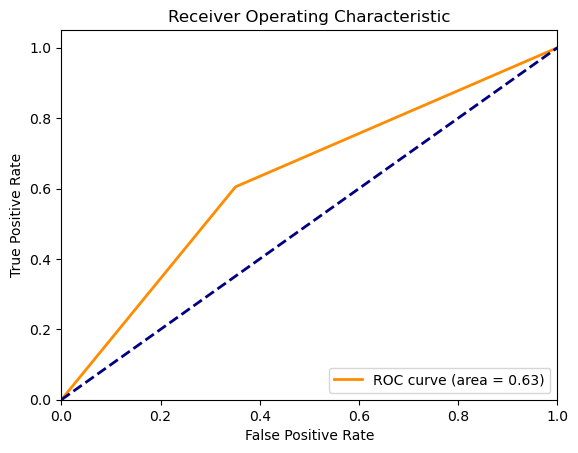

In [79]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

A métrica AUC do modelo (0,63), indica uma qualidade fraca do modelo, pois quanto mais próximo de 0,5, mais próximo do acaso.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



In [ ]:
# seu código aqui

**A**  
Regressão Logística é um algoritmo usado para prever categorias, geralmente respostas do tipo sim ou não. Ela calcula a probabilidade de cada resultado e escolhe a opção mais provável.

**B**  
A regressão logística é um modelo de classificação porque seu resultado final é uma categoria e não um valor contínuo.

**C**  
A regressão logística e a regressão linear têm em comum o fato de que ambas analisam a relação entre variáveis para fazer previsões e atribuem pesos (coeficientes) às características dos dados.
Mas Regressão Linear prevê um valor numérico e a Regressão Logísticaoutra prevê uma categoria.
